# 4 — Comparing elasticity models, and choosing one

We now have seven tuned models and no labels. This notebook answers the two questions that
remain, both of which can be settled from observed data:

1. **Is the heterogeneity real?** A model that outputs a different elasticity for every
   product has made a strong claim. There is a way to check it that does not assume the
   answer.
2. **What is it worth?** Turn each model into the pricing decision it implies and estimate
   what that decision earns — always measured against the best *uniform* price move,
   because a model that cannot beat one flat number has not earned its complexity.

The key idea throughout: **you cannot check one row's elasticity, but you can check a
group's**, because a group contains price variation. Everything below is a way of
exploiting that.

In [1]:
import sys, pathlib, time, warnings
sys.path.insert(0, str(pathlib.Path.cwd().parent))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from elasticity_lab.bench import real_frame, synth_frame, frame_summary
from elasticity_lab.models import MODEL_REGISTRY, build_model
from elasticity_lab.splits import RollingOriginSplit
from elasticity_lab.tuning import CausalScorer, tune
from elasticity_lab.evaluation import (predictive_metrics, gates, blp_calibration,
                                       policy_value, oracle_metrics, evaluate_model,
                                       compare_models, elasticity_summary)

pd.set_option("display.width", 210); pd.set_option("display.max_columns", 60)
plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": True,
                     "grid.alpha": 0.25, "axes.spines.top": False,
                     "axes.spines.right": False})
INK, ACCENT, WARN, GOOD = "#3a3a3a", "#1f6feb", "#c0392b", "#1a7f5a"

N_PRODUCTS = 700
syn = synth_frame(N_PRODUCTS, confounding_price=0.6, confounding_demand=0.8)
real = real_frame(N_PRODUCTS)
sp = RollingOriginSplit(n_splits=4, horizon=8, min_train_weeks=30)
syn_scorer, real_scorer = CausalScorer(syn, sp, seed=0), CausalScorer(real, sp, seed=0)
print(frame_summary(real).to_string())

rows                                          38020
products                                        700
weeks                                           103
first_week                               2009-12-07
last_week                                2011-12-05
median_weeks_per_product                       50.0
sd_log_price_within_product                0.234327
source                         UCI Online Retail II


## 4.1 GATES — grouped average treatment effects

Sort the validation rows by the model's predicted elasticity, cut into five bins, and then
**re-estimate each bin's elasticity from the data**, orthogonally:

$$\hat\varepsilon_g = -\frac{\langle \tilde t, \tilde y\rangle_g}{\langle \tilde t, \tilde t\rangle_g}$$

where $\tilde y, \tilde t$ are the residualised outcome and price from §3.2. The predicted
column is what the model says; the estimated column is what the data say.

**If the model's ranking is real, the estimated column rises across bins.** If the model's
"heterogeneity" is noise, the estimated column is flat no matter how much the predicted
column varies — and a flat estimated column next to a steep predicted one is the single
most common way an elasticity model is wrong while looking fine.

This is the continuous-treatment analogue of Chernozhukov, Demirer, Duflo & Fernández-Val
(2018). The residuals must come from nuisance models that never saw the validation rows,
or the bins inherit the nuisance model's overfitting; `CausalScorer` guarantees that.

In [2]:
fold = len(syn_scorer.folds_) - 1
tr, va = syn_scorer.folds_[fold]
res = syn_scorer.residuals(fold)

het = {"r_learner": build_model("r_learner", n_folds=3),
       "lgbm_demand": build_model("lgbm_demand"),
       "shrunk_per_product": build_model("shrunk_per_product")}
tables = {}
for name, m in het.items():
    m.fit(syn.iloc[tr])
    e = np.asarray(m.elasticity(syn.iloc[va]), float)
    g = gates(res["ry"], res["rt"], e, n_groups=5)
    # the synthetic panel lets us add the column the real panel can never have
    edges = np.quantile(e, np.linspace(0, 1, 6)); edges[0], edges[-1] = -np.inf, np.inf
    b = np.clip(np.searchsorted(edges, e, side="right") - 1, 0, 4)
    truth = syn.iloc[va].true_elasticity.to_numpy(float)
    g["eps_TRUE"] = [truth[b == k].mean() for k in range(5)]
    tables[name] = g
    print(f"\n=== {name} ===  monotone: {g.attrs['monotone']}   "
          f"spread {g.attrs['spread']:+.3f} (t = "
          f"{g.attrs['spread']/g.attrs['spread_se']:+.2f})")
    print(g[["group", "n", "eps_predicted", "eps_estimated", "se", "eps_TRUE"]]
          .to_string(index=False, float_format=lambda v: f"{v:+.4f}"))


=== r_learner ===  monotone: False   spread +0.475 (t = +1.73)
 group   n  eps_predicted  eps_estimated      se  eps_TRUE
     1 598        -0.6687        +1.2800 +0.2254   +1.3143
     2 598        +0.8764        +1.0160 +0.1319   +1.5500
     3 597        +1.3081        +1.2656 +0.1119   +1.7657
     4 598        +1.7279        +1.5079 +0.1144   +1.9100
     5 598        +2.9740        +1.7555 +0.1568   +2.0880



=== lgbm_demand ===  monotone: False   spread +0.274 (t = +1.15)
 group   n  eps_predicted  eps_estimated      se  eps_TRUE
     1 598        -0.1654        +1.2117 +0.2137   +1.4510
     2 598        +0.3208        +1.1116 +0.1248   +1.6187
     3 597        +0.7451        +1.4522 +0.1331   +1.7495
     4 598        +1.2906        +1.5036 +0.1420   +1.8491
     5 598        +2.5469        +1.4860 +0.1073   +1.9598



=== shrunk_per_product ===  monotone: True   spread +1.263 (t = +6.30)
 group   n  eps_predicted  eps_estimated      se  eps_TRUE
     1 593        -0.5144        +0.7114 +0.1817   +1.0193
     2 601        +0.1974        +0.8905 +0.1209   +1.5404
     3 597        +0.5844        +0.9642 +0.1304   +1.5929
     4 597        +1.0565        +1.3383 +0.1195   +1.9732
     5 601        +1.7440        +1.9740 +0.0845   +2.4935


The `eps_TRUE` column exists only because this is the synthetic panel — it is the
audit of the audit. Where `eps_estimated` tracks `eps_TRUE`, the GATES procedure is
working, and that is the evidence that lets us rely on it in §4.6 where `eps_TRUE` does
not exist.

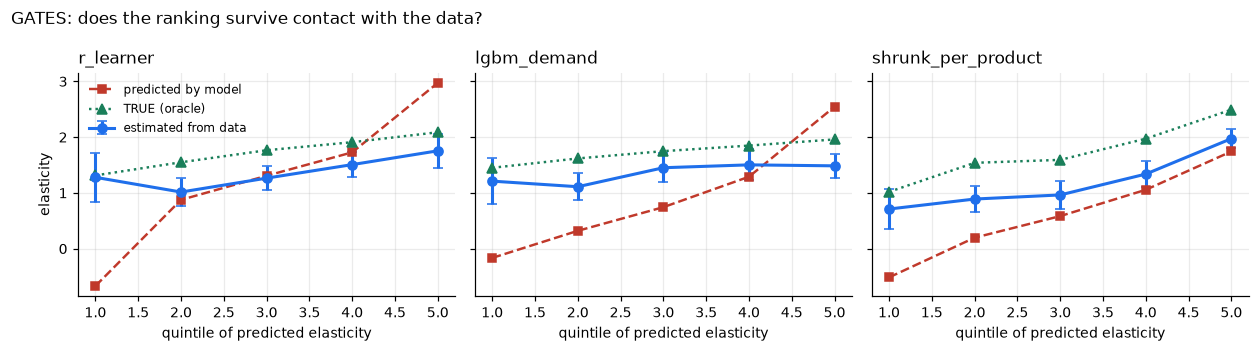

In [3]:
fig, ax = plt.subplots(1, 3, figsize=(11.5, 3.2), sharey=True)
for a, (name, g) in zip(ax, tables.items()):
    a.errorbar(g.group, g.eps_estimated, yerr=1.96*g.se, fmt="o-", color=ACCENT,
               lw=2, ms=6, capsize=3, label="estimated from data")
    a.plot(g.group, g.eps_predicted, "s--", color=WARN, lw=1.6, ms=5,
           label="predicted by model")
    a.plot(g.group, g.eps_TRUE, "^:", color=GOOD, lw=1.6, ms=6, label="TRUE (oracle)")
    a.set_xlabel("quintile of predicted elasticity")
    a.set_title(name, loc="left")
ax[0].set_ylabel("elasticity"); ax[0].legend(frameon=False, fontsize=8)
fig.suptitle("GATES: does the ranking survive contact with the data?", x=.01, ha="left")
fig.tight_layout()

## 4.2 BLP — is the *scale* of the heterogeneity right?

GATES checks the ordering. The Best-Linear-Predictor test checks the magnitude. Regress

$$\tilde y \;=\; \beta_0\,\tilde t \;+\; \beta_1\,\tilde t\,\bigl(\hat\varepsilon(x) - \overline{\hat\varepsilon}\bigr) \;+\; \text{error}$$

* $-\beta_0$ estimates the average elasticity;
* $\beta_1 \approx -1$ means the predicted spread is correctly scaled (negative because
  $\theta = -\varepsilon$);
* $\beta_1 \approx 0$ means the predictions carry no usable heterogeneity;
* $|\beta_1| < 1$ means the model **over-states** how much elasticities differ — the usual
  outcome for a flexible learner, which reads noise as signal.

The $t$-statistic on $\beta_1$ is a formal test that the model detects any real
heterogeneity at all.

In [4]:
rows = []
for name, m in het.items():
    e = np.asarray(m.elasticity(syn.iloc[va]), float)
    b = blp_calibration(res["ry"], res["rt"], e)
    o = oracle_metrics(e, syn.iloc[va].true_elasticity.to_numpy(float))
    rows.append({"model": name, **b, "oracle_corr": o["oracle_corr"],
                 "oracle_rmse": o["oracle_rmse"]})
blp = pd.DataFrame(rows)
blp[["model", "blp_avg_elasticity", "beta1", "beta1_se", "beta1_t", "implied_spread",
     "heterogeneity_detected", "oracle_corr", "oracle_rmse"]] \
   .style.format({c: "{:+.4f}" for c in
                  ["blp_avg_elasticity", "beta1", "beta1_se", "beta1_t", "implied_spread",
                   "oracle_corr",
                   "oracle_rmse"]}).hide(axis="index")

model,blp_avg_elasticity,beta1,beta1_se,beta1_t,implied_spread,heterogeneity_detected,oracle_corr,oracle_rmse
r_learner,+1.3639,-0.2513,+0.0658,-3.8186,+0.3768,True,+0.3467,+1.4971
lgbm_demand,+1.3468,-0.1274,+0.0660,-1.9284,+0.1333,False,+0.2275,+1.3614
shrunk_per_product,+1.1549,-0.6028,+0.0614,-9.8172,+0.4850,True,+0.7128,+1.2508


On the synthetic panel we can check the check: `beta1_t` is computed from observed data
only, `oracle_corr` from the truth. Where they agree, the BLP test is doing its job — which
is the evidence that lets us trust it on the real panel, where `oracle_corr` does not
exist.

## 4.3 Decision value — what is the model worth?

Log revenue is $\log p + \log q$, so nudging log price by $d$ changes log revenue by
$d\,(1 - \varepsilon)$: raise the price where demand is **inelastic** ($\varepsilon < 1$),
cut it where it is **elastic**. The model's implied policy is therefore

$$d(x) = +\delta \ \text{ if } \hat\varepsilon(x) < 1, \qquad -\delta \ \text{ otherwise.}$$

Evaluating it needs the *true* elasticity, which we do not have — so it is estimated
group-wise, exactly as in GATES: bin by $\hat\varepsilon$, identify each bin's elasticity
from its own price variation, and average.

**The reference point is the whole point.** `value_best_uniform` is the best single
$\pm\delta$ applied to everyone, including doing nothing. `lift_over_uniform` is the
difference — and it is routinely zero or negative. Reporting it is what stops a model from
being adopted on the strength of a good-looking score.

In [5]:
rows = []
for name, m in het.items():
    e = np.asarray(m.elasticity(syn.iloc[va]), float)
    rows.append({"model": name, **policy_value(res["ry"], res["rt"], e, delta=0.05)})
# a constant-elasticity model, for contrast: it prices everything the same way
m_const = build_model("dml_partialling", n_folds=3).fit(syn.iloc[tr])
e_const = np.asarray(m_const.elasticity(syn.iloc[va]), float)
rows.append({"model": "dml_partialling (constant)",
             **policy_value(res["ry"], res["rt"], e_const, delta=0.05)})
pv = pd.DataFrame(rows)
pv.style.format({c: "{:+.5f}" for c in pv.columns if c != "model"}).hide(axis="index")

model,value_model,value_uniform_up,value_uniform_down,value_best_uniform,lift_over_uniform,pct_priced_up
r_learner,+0.01242,-0.01825,+0.01825,+0.01825,-0.00583,+0.34192
lgbm_demand,+0.00208,-0.01765,+0.01765,+0.01765,-0.01557,+0.60120
shrunk_per_product,+0.01506,-0.00885,+0.00885,+0.00885,+0.00621,+0.67113
dml_partialling (constant),+0.01747,-0.01747,+0.01747,+0.01747,+0.00000,+0.00000


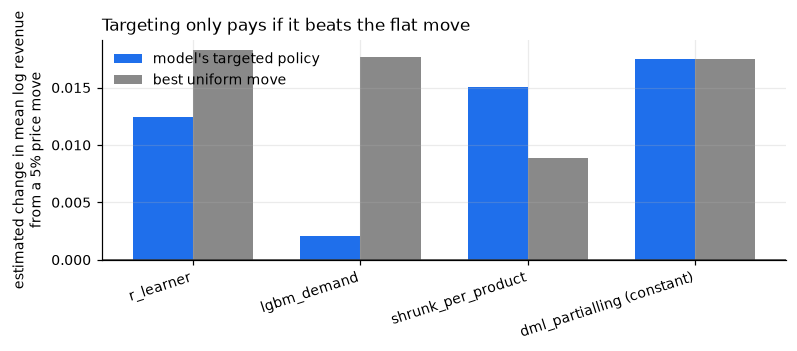

In [6]:
fig, ax = plt.subplots(figsize=(7.4, 3.2))
xs = np.arange(len(pv)); w = .36
ax.bar(xs - w/2, pv.value_model, w, label="model's targeted policy", color=ACCENT)
ax.bar(xs + w/2, pv.value_best_uniform, w, label="best uniform move", color=INK, alpha=.6)
ax.axhline(0, color=INK, lw=1)
ax.set_xticks(xs); ax.set_xticklabels(pv.model, rotation=18, ha="right")
ax.set_ylabel("estimated change in mean log revenue\nfrom a 5% price move")
ax.set_title("Targeting only pays if it beats the flat move", loc="left")
ax.legend(frameon=False)
fig.tight_layout()

## 4.4 Everything at once, on the synthetic panel

`evaluate_model` runs the full battery on the last fold: predictive metrics, R-loss and its
two normalisations, BLP, GATES, policy value, and — because this is the synthetic panel —
the oracle comparison the others are approximating.

In [7]:
models = {n: build_model(n) for n in MODEL_REGISTRY}
allm = compare_models(models, syn, syn_scorer, fold=-1, truth_col="true_elasticity")
cols = ["name", "avg_elasticity", "blp_avg_elasticity", "eps_sd", "rmse",
        "rloss_skill", "rloss_vs_constant",
        "beta1", "beta1_t", "implied_spread", "gates_monotone", "gates_spread",
        "lift_over_uniform",
        "oracle_rmse", "oracle_bias", "oracle_corr"]
allm[cols].sort_values("oracle_rmse").style.format(
    {c: "{:+.4f}" for c in cols if c not in ("name", "gates_monotone")}
).hide(axis="index")

name,avg_elasticity,blp_avg_elasticity,eps_sd,rmse,rloss_skill,rloss_vs_constant,beta1,beta1_t,implied_spread,gates_monotone,gates_spread,lift_over_uniform,oracle_rmse,oracle_bias,oracle_corr
dml_partialling,+1.2458,+1.3494,+0.0000,+0.8568,+0.2314,-0.0018,+nan,+nan,+0.0000,None,+nan,+0.0000,+0.8452,-0.4798,+nan
twoway_fe,+0.9652,+1.3494,+0.0000,+0.8556,+0.2139,-0.0246,+nan,+nan,+0.0000,None,+nan,-0.0349,+1.0307,-0.7604,+nan
pooled_loglog,+0.8038,+1.3494,+0.0000,+1.4752,+0.1947,-0.0496,+nan,+nan,+0.0000,None,+nan,-0.0349,+1.1550,-0.9218,+nan
poisson_glm,+0.6950,+1.3494,+0.0000,+2.1509,+0.1780,-0.0713,+nan,+nan,+0.0000,None,+nan,-0.0349,+1.2435,-1.0306,+nan
shrunk_per_product,+0.6160,+1.1549,+0.8046,+1.3568,+0.2322,-0.0007,-0.6028,-9.8172,+0.4850,True,+1.2626,+0.0062,+1.2508,-1.1095,+0.7128
lgbm_demand,+0.9477,+1.3468,+1.0466,+0.8510,+0.0936,-0.1813,-0.1274,-1.9284,+0.1333,False,+0.2744,-0.0156,+1.3614,-0.7779,+0.2275
r_learner,+1.2522,+1.3067,+1.4058,+0.8568,+0.1402,-0.1206,-0.1998,-2.2674,+0.2809,False,+0.6951,+0.0018,+1.4260,-0.4733,+0.3328


### Which observable metric would have picked the right model?

This is the payoff of having a synthetic panel at all. Rank the models by each *observable*
metric and see which ranking matches the ranking by oracle error. Whichever observable
metric wins here is the one to trust on the real panel.

In [8]:
obs = ["rmse", "rloss_skill", "rloss_vs_constant", "beta1_t", "lift_over_uniform"]
sign = {"rmse": +1, "rloss_skill": -1, "rloss_vs_constant": -1, "beta1_t": +1,
        "lift_over_uniform": -1}   # +1 = lower is better, matching oracle_rmse
d = allm.dropna(subset=["oracle_rmse"] + obs)
sel = pd.DataFrame([{"observable metric": c,
                     "rho with oracle_rmse":
                         sign[c] * d[[c, "oracle_rmse"]].corr("spearman").iloc[0, 1]}
                    for c in obs]).sort_values("rho with oracle_rmse", ascending=False)
sel.style.format({"rho with oracle_rmse": "{:+.3f}"}).hide(axis="index")

observable metric,rho with oracle_rmse
rloss_skill,+0.500
beta1_t,+0.500
rloss_vs_constant,+0.500
lift_over_uniform,+0.500
rmse,-0.500


Positive means the metric ranks models the way the truth does. Predictive RMSE sitting
low or negative in this table is the same finding as notebook 3, now at the level of *model
choice* rather than hyperparameter choice.

## 4.5 A specification check: does the winner depend on the DGP?

Every conclusion so far comes from one synthetic world. A benchmark that only works in the
world it was designed for is worthless, so we vary the world:

* **exogenous prices** — no confounding at all, where the naive estimator should be fine;
* **heavy confounding** — where orthogonalisation should pay most;
* **Poisson outcome** — counts rather than lognormal, which should suit the Poisson GLM and
  penalise the log-scale models.

If the ranking is stable across these, it is a property of the methods. If it flips, that
is worth knowing too — and it is the honest version of "no method is universally best"
(Curth & van der Schaar, 2021).

In [9]:
from elasticity_lab.simulate import SyntheticConfig

worlds = {
    "exogenous price":  SyntheticConfig(confounding_price=0.0, confounding_demand=0.0),
    "mild confounding": SyntheticConfig(confounding_price=0.35, confounding_demand=0.8),
    "heavy confounding": SyntheticConfig(confounding_price=1.0, confounding_demand=1.2),
    "poisson outcome":  SyntheticConfig(confounding_price=0.35, confounding_demand=0.8,
                                        outcome="poisson"),
}
rows = []
for wname, cfg in worlds.items():
    w = synth_frame(400, config=cfg)
    for mname in MODEL_REGISTRY:
        m = build_model(mname).fit(w)
        e = np.asarray(m.elasticity(w), float)
        t = w.true_elasticity.to_numpy(float)
        rows.append({"world": wname, "model": mname,
                     "bias": float(e.mean() - t.mean()),
                     "oracle_rmse": float(np.sqrt(np.mean((e - t) ** 2)))})
robust = pd.DataFrame(rows)
robust.pivot(index="model", columns="world", values="bias") \
      .style.format("{:+.3f}").background_gradient(cmap="RdYlGn_r", vmin=-1.5, vmax=1.5)

world,exogenous price,heavy confounding,mild confounding,poisson outcome
model,,,,
dml_partialling,+0.081,-0.172,-0.113,-0.459
lgbm_demand,+0.079,-0.680,-0.702,-0.899
poisson_glm,+0.144,-0.514,-1.161,-1.186
pooled_loglog,+0.078,-0.813,-0.814,-1.017
r_learner,-0.036,-0.341,-0.266,-0.572
shrunk_per_product,+0.285,-1.144,-1.196,-1.303
twoway_fe,+0.175,-0.831,-1.448,-1.472


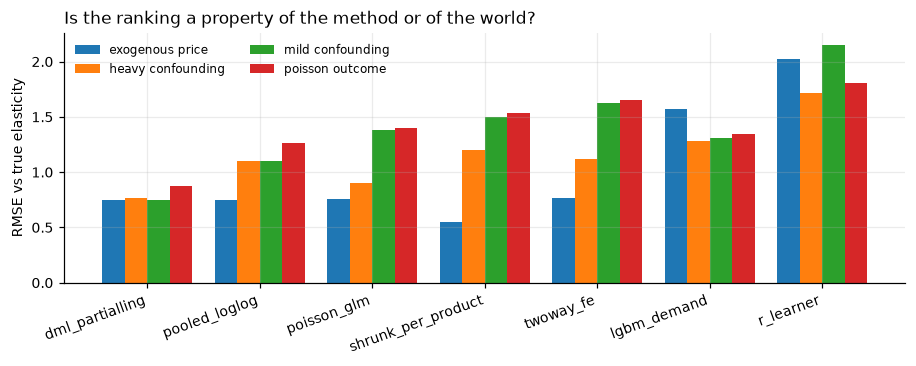

In [10]:
fig, ax = plt.subplots(figsize=(8.4, 3.4))
piv = robust.pivot(index="model", columns="world", values="oracle_rmse")
piv = piv.loc[piv.mean(axis=1).sort_values().index]
xs = np.arange(len(piv))
for i, w in enumerate(piv.columns):
    ax.bar(xs + (i - 1.5) * 0.2, piv[w], 0.2, label=w)
ax.set_xticks(xs); ax.set_xticklabels(piv.index, rotation=20, ha="right")
ax.set_ylabel("RMSE vs true elasticity"); ax.legend(frameon=False, fontsize=8, ncol=2)
ax.set_title("Is the ranking a property of the method or of the world?", loc="left")
fig.tight_layout()

## 4.6 The real panel: tune, evaluate, choose

Now the same battery on data with no answer key, using the R-loss to tune (the conclusion
of notebook 3) and the grouped diagnostics to judge.

In [11]:
N_TRIALS = 12
tuned, chosen = {}, {}
for name in MODEL_REGISTRY:
    t0 = time.time()
    r = tune(name, real, objective="rloss", n_trials=N_TRIALS, scorer=real_scorer, seed=0)
    tuned[name] = r["best_params"]
    chosen[name] = build_model(name, **r["best_params"])
    print(f"{name:20s} rloss={r['best_metrics']['rloss']:.4f}  ({time.time()-t0:.0f}s)")

final = compare_models(chosen, real, real_scorer, fold=-1)
fcols = ["name", "avg_elasticity", "blp_avg_elasticity", "eps_sd", "rmse", "r2",
         "rloss_skill",
         "rloss_vs_constant", "beta1", "beta1_t", "implied_spread",
         "heterogeneity_detected",
         "gates_monotone", "gates_spread", "value_model", "value_best_uniform",
         "lift_over_uniform"]
final[fcols].sort_values("rloss_vs_constant", ascending=False).style.format(
    {c: "{:+.4f}" for c in fcols
     if c not in ("name", "heterogeneity_detected", "gates_monotone")}
).hide(axis="index")

pooled_loglog        rloss=2.3314  (11s)


twoway_fe            rloss=2.3323  (16s)


poisson_glm          rloss=2.3303  (129s)


lgbm_demand          rloss=2.5964  (97s)


dml_partialling      rloss=2.3457  (303s)


r_learner            rloss=2.3301  (350s)


shrunk_per_product   rloss=2.3326  (5s)


name,avg_elasticity,blp_avg_elasticity,eps_sd,rmse,r2,rloss_skill,rloss_vs_constant,beta1,beta1_t,implied_spread,heterogeneity_detected,gates_monotone,gates_spread,value_model,value_best_uniform,lift_over_uniform
r_learner,+1.4747,+1.3690,+0.4573,+0.9618,+0.6921,+0.1224,+0.0025,-0.6297,-3.0390,+0.2879,True,False,+1.1090,+0.0206,+0.0222,-0.0015
dml_partialling,+1.3775,+1.3004,+0.0000,+0.9232,+0.7163,+0.1198,-0.0005,+nan,+nan,+0.0000,False,None,+nan,+0.0150,+0.0150,+0.0000
twoway_fe,+1.4559,+1.3004,+0.0000,+10.8745,-38.3620,+0.1185,-0.0020,+nan,+nan,+0.0000,False,None,+nan,+0.0150,+0.0150,+0.0000
poisson_glm,+1.4694,+1.3004,+0.0000,+1.1195,+0.5828,+0.1181,-0.0023,+nan,+nan,+0.0000,False,None,+nan,+0.0150,+0.0150,+0.0000
pooled_loglog,+1.5614,+1.3004,+0.0000,+0.9239,+0.7159,+0.1153,-0.0055,+nan,+nan,+0.0000,False,None,+nan,+0.0150,+0.0150,+0.0000
shrunk_per_product,+1.6089,+1.3176,+0.0017,+1.1596,+0.5524,+0.1135,-0.0076,-127.0613,-3.0075,+0.2188,True,False,+0.3417,+0.0183,+0.0183,+0.0000
lgbm_demand,+1.8275,+1.3735,+1.1035,+1.2489,+0.4808,+0.0557,-0.0732,-0.1225,-1.5370,+0.1352,False,False,+0.0449,+0.0135,+0.0182,-0.0048


best by rloss_vs_constant: r_learner
 group   n  eps_predicted  eps_estimated      se
     1 596        +0.8228        +1.1060 +0.1524
     2 600        +1.2869        +1.4308 +0.1640
     3 597        +1.4991        +1.0588 +0.1793
     4 597        +1.6630        +1.4014 +0.1992
     5 599        +2.0995        +2.2150 +0.2869


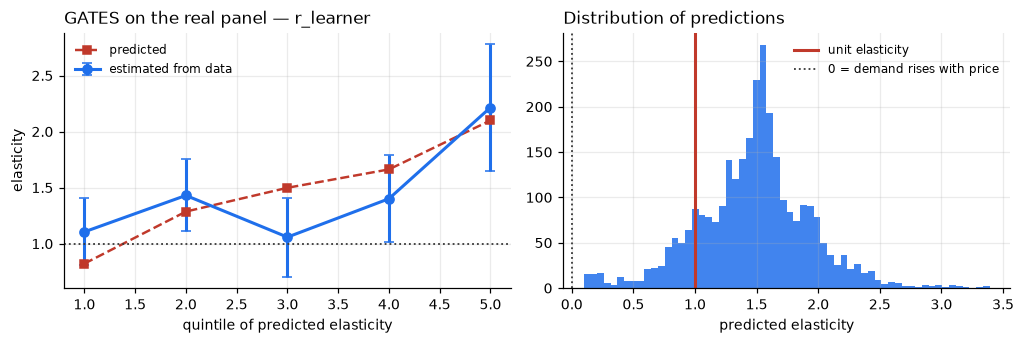

In [12]:
best_het = final.sort_values("rloss_vs_constant", ascending=False).iloc[0]["name"]
m = chosen[best_het]
r = evaluate_model(m, real, real_scorer, fold=-1)
g = r["_gates_table"]
print(f"best by rloss_vs_constant: {best_het}")
print(g[["group", "n", "eps_predicted", "eps_estimated", "se"]]
      .to_string(index=False, float_format=lambda v: f"{v:+.4f}"))

fig, ax = plt.subplots(1, 2, figsize=(9.4, 3.2))
ax[0].errorbar(g.group, g.eps_estimated, yerr=1.96*g.se, fmt="o-", color=ACCENT,
               lw=2, ms=6, capsize=3, label="estimated from data")
ax[0].plot(g.group, g.eps_predicted, "s--", color=WARN, lw=1.6, ms=5, label="predicted")
ax[0].axhline(1.0, color=INK, ls=":", lw=1.2)
ax[0].set_xlabel("quintile of predicted elasticity"); ax[0].set_ylabel("elasticity")
ax[0].set_title(f"GATES on the real panel — {best_het}", loc="left")
ax[0].legend(frameon=False, fontsize=8)
ax[1].hist(np.clip(r["_elasticity"], -2, 6), bins=60, color=ACCENT, alpha=.85)
ax[1].axvline(1.0, color=WARN, lw=2, label="unit elasticity")
ax[1].axvline(0.0, color=INK, lw=1.2, ls=":", label="0 = demand rises with price")
ax[1].set_xlabel("predicted elasticity"); ax[1].legend(frameon=False, fontsize=8)
ax[1].set_title("Distribution of predictions", loc="left")
fig.tight_layout()

The dotted line at 1.0 in the left panel is the decision boundary: products estimated
below it are inelastic, and raising their price raises revenue. Where the *estimated*
(blue) series crosses it is the actionable finding; where only the *predicted* (red) series
crosses it, the model is claiming something the data do not support.

## 4.7 A selection rule

Putting the pieces together, in the order they should be applied:

1. **Tune on the R-loss**, never on predictive RMSE (notebook 3).
2. **Check `rloss_vs_constant` on held-out data.** ≤ 0 means the heterogeneity does not
   beat one flat number — use the constant-elasticity model, which will be better estimated
   and easier to defend.
3. **Check the BLP `beta1_t`.** Not significantly negative means no detectable
   heterogeneity, whatever the spread of the predictions looks like.
4. **Check GATES monotonicity.** A non-monotone estimated column means the ranking is
   unreliable even if the average is fine.
5. **Check `lift_over_uniform`.** If targeting does not beat the best flat move, the
   complexity is not paying for itself.
6. **Report nested-CV numbers**, and sanity-check `pct_negative` — a model producing many
   upward-sloping demand curves is telling you its predictions are noise.

Steps 2–5 are all computable without ever knowing a single true elasticity. That is the
point of the whole exercise.

In [13]:
verdict = final.copy()
verdict["passes_2_beats_constant"] = verdict.rloss_vs_constant > 0
verdict["passes_3_blp"] = verdict.beta1_t < -1.96
verdict["passes_4_gates"] = verdict.gates_monotone.fillna(False)
verdict["passes_5_policy"] = verdict.lift_over_uniform > 0
pf = [c for c in verdict.columns if c.startswith("passes_")]
verdict["checks_passed"] = verdict[pf].sum(axis=1)
verdict[["name"] + pf + ["checks_passed", "avg_elasticity"]] \
    .sort_values("checks_passed", ascending=False).style.hide(axis="index")

name,passes_2_beats_constant,passes_3_blp,passes_4_gates,passes_5_policy,checks_passed,avg_elasticity
r_learner,True,True,False,False,2,1.474695
shrunk_per_product,False,True,False,False,1,1.608897
pooled_loglog,False,False,False,False,0,1.561363
twoway_fe,False,False,False,False,0,1.455890
poisson_glm,False,False,False,False,0,1.469386
lgbm_demand,False,False,False,False,0,1.827490
dml_partialling,False,False,False,False,0,1.377472


A constant-elasticity model failing checks 3–5 is **not** a mark against it: it never
claimed heterogeneity, so tests of heterogeneity do not apply. The checks decide between
models that *do* make the claim, and tell you when to fall back to one that does not.

## 4.8 Summary

* Heterogeneity is checkable without labels, at the level of **groups**: GATES for the
  ranking, BLP for the scale, policy value for the money.
* The reference for every heterogeneous claim is the **best constant** — fitted on the same
  held-out data, so beating it means something.
* Which model wins depends on the world (§4.5). Report the range, not one number.
* On the real panel, the honest deliverable is: an average elasticity with a confidence
  interval, a statement of whether per-product variation is detectable, and — if it is —
  what acting on it is estimated to be worth.